<a href="https://colab.research.google.com/github/Camper-Lingo/CP1_SERS/blob/main/desafio_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Fonte dos dados
API pública de Carga Verificada do ONS:

Portal: https://dados.ons.org.br/
Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada
Neste notebook será utilizada inicialmente a área SP — São Paulo, no período de 01/08/2025 a 07/08/2025.

##2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##3. Consulta à API


In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


##4. Preparação inicial do JSON

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

In [6]:
# DESAFIO 1

dados = pd.DataFrame(registros)

print("Primeiros registros:")
display(dados.head())

print("\nQuantidade de linhas e colunas:", dados.shape)

print("\nNomes dos atributos:")
print(list(dados.columns))

print("\nInfo:")
dados.info()

print("\nDescribe:")
display(dados.describe(include='all'))

Primeiros registros:


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0



Quantidade de linhas e colunas: (336, 11)

Nomes dos atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganao

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


In [7]:
# DESAFIO 2

# 1. Renomear as colunas reais
mapa_nomes = {
    "din_referenciautc": "data_hora",
    "cod_areacarga": "area",
    "val_cargaglobal": "carga_mw"
}
dados_renomeado = dados.rename(columns=mapa_nomes)

# 2. Novo DataFrame só com o necessário
colunas_necessarias = ["data_hora", "area", "carga_mw"]
dados_final = dados_renomeado[colunas_necessarias].copy()

# 3 e 4. Valores ausentes
print("Valores ausentes por coluna:")
print(dados_final.isna().sum())

# 5. Carga em formato numérico?
print("Tipo da coluna carga_mw:")
print(dados_final["carga_mw"].dtype)
dados_final["carga_mw"] = pd.to_numeric(dados_final["carga_mw"], errors="coerce")

# 6. Data/hora
print("Tipo da coluna data_hora:")
print(dados_final["data_hora"].dtype)
dados_final["data_hora"] = pd.to_datetime(dados_final["data_hora"], errors="coerce")

print("DataFrame tratado:")
display(dados_final.head())

Valores ausentes por coluna:
data_hora    0
area         0
carga_mw     0
dtype: int64
Tipo da coluna carga_mw:
float64
Tipo da coluna data_hora:
object
DataFrame tratado:


,data_hora,area,carga_mw
0,2025-08-01 03:30:00+00:00,SP,15913.618
1,2025-08-01 04:00:00+00:00,SP,15251.414
2,2025-08-01 04:30:00+00:00,SP,14606.733
3,2025-08-01 05:00:00+00:00,SP,14182.290
4,2025-08-01 05:30:00+00:00,SP,13838.488


In [8]:
# DESAFIO 3

carga_min = dados_final["carga_mw"].min()
carga_max = dados_final["carga_mw"].max()
carga_media = dados_final["carga_mw"].mean()
carga_mediana = dados_final["carga_mw"].median()
amplitude = carga_max - carga_min
total_medicoes = dados_final["carga_mw"].count()

print("Carga mínima (MW):", round(carga_min, 2))
print("Carga máxima (MW):", round(carga_max, 2))
print("Carga média (MW):", round(carga_media, 2))
print("Mediana (MW):", round(carga_mediana, 2))
print("Amplitude (MW):", round(amplitude, 2))
print("Total de medições:", total_medicoes)

diferenca_percentual = (carga_max - carga_media) / carga_media * 100
print("Diferença do máximo em relação à média (%):", round(diferenca_percentual, 1))

Carga mínima (MW): 12139.25
Carga máxima (MW): 23185.31
Carga média (MW): 17870.83
Mediana (MW): 18199.13
Amplitude (MW): 11046.06
Total de medições: 336
Diferença do máximo em relação à média (%): 29.7


**O valor máximo está muito distante do comportamento médio observado?**

Não muito distante, mas é uma diferença perceptível. A carga máxima (23.185,31 MW) fica 29,7% acima
da carga média (17.870,83 MW). Esse valor está na faixa de uma variação esperada de pico de demanda
diário — não é um outlier extremo, mas mostra uma diferença relevante entre a carga observada no dia
a dia e o pico pontual.

Outro ponto que reforça isso: a mediana (18.199,13 MW) é ligeiramente maior que a média (17.870,83 MW),
o que indica uma leve assimetria da distribuição para valores mais baixos — existem alguns registros
de carga bem baixa (perto do mínimo de 12.139,25 MW) puxando a média pra baixo, enquanto a maior parte
das medições fica concentrada perto ou acima da mediana. Isso é coerente com o padrão típico de curva
de carga elétrica: vales noturnos baixos e picos diurnos mais altos.

In [9]:
# DESAFIO 4

limiar_alta_demanda = carga_max * 0.9

alta_demanda = dados_final[dados_final["carga_mw"] > limiar_alta_demanda].copy()

qtd_alta_demanda = len(alta_demanda)
percentual_alta_demanda = qtd_alta_demanda / total_medicoes * 100

pico_valor = alta_demanda["carga_mw"].max()
pico_registro = alta_demanda.loc[alta_demanda["carga_mw"].idxmax()]

print("Limiar de alta demanda (90% do máximo, em MW):", round(limiar_alta_demanda, 2))
print("Registros em alta demanda:", qtd_alta_demanda)
print("Percentual do total (%):", round(percentual_alta_demanda, 1))
print("Valor de pico (MW):", round(pico_valor, 2))
print("Momento do pico:", pico_registro["data_hora"])

Limiar de alta demanda (90% do máximo, em MW): 20866.78
Registros em alta demanda: 50
Percentual do total (%): 14.9
Valor de pico (MW): 23185.31
Momento do pico: 2025-08-01 22:00:00+00:00


**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

Uma parcela pequena. Os registros de alta demanda somam apenas 50 de um total de 336 medições, o que
representa 14,9% do período analisado. Isso significa que a carga permanece acima de 90% do valor
máximo em uma fração pequena do tempo — a maior parte das medições (85,1%) fica abaixo desse patamar.
Isso é consistente com o padrão esperado de uma curva de carga elétrica, em que os picos de consumo se
concentram em janelas específicas do dia, e não se mantêm ao longo de todo o período.


In [10]:
# DESAFIO 5

# Critério escolhido: carga acima da média
acima_da_media = dados_final[dados_final["carga_mw"] > carga_media].copy()

qtd_acima_media = len(acima_da_media)
percentual_acima_media = qtd_acima_media / total_medicoes * 100

print("Critério: carga acima da média")
display(acima_da_media.head())
print("Quantidade de registros:", qtd_acima_media)
print("Percentual do total (%):", round(percentual_acima_media, 1))


Critério: carga acima da média


,data_hora,area,carga_mw
15,2025-08-01 11:00:00+00:00,SP,18096.023
16,2025-08-01 11:30:00+00:00,SP,18629.395
17,2025-08-01 12:00:00+00:00,SP,18825.176
18,2025-08-01 12:30:00+00:00,SP,19056.504
19,2025-08-01 13:00:00+00:00,SP,19427.822


Quantidade de registros: 184
Percentual do total (%): 54.8


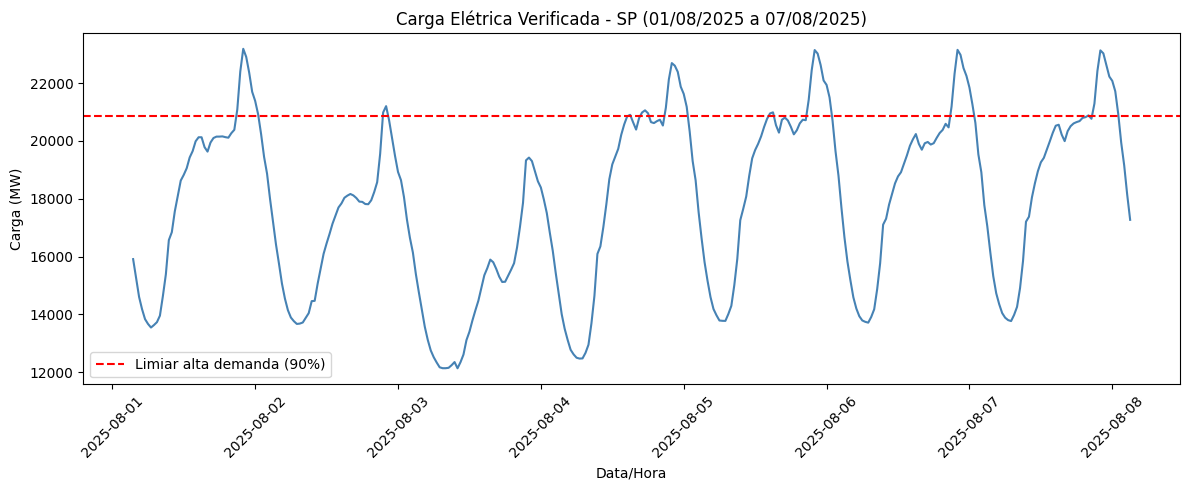

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(dados_final["data_hora"], dados_final["carga_mw"], color="steelblue")
plt.axhline(limiar_alta_demanda, color="red", linestyle="--", label="Limiar alta demanda (90%)")
plt.title("Carga Elétrica Verificada - SP (01/08/2025 a 07/08/2025)")
plt.xlabel("Data/Hora")
plt.ylabel("Carga (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O gráfico mostra um padrão claramente cíclico, com 7 ondas bem definidas — uma para cada dia do
período analisado (01/08 a 07/08/2025). Em cada ciclo, a carga cai para valores mínimos (entre
12.000 e 14.000 MW) durante a madrugada e sobe até picos (entre 20.000 e 23.000 MW) ao longo do dia,
ultrapassando o limiar de alta demanda (linha vermelha, ~20.867 MW) em vários momentos. Esse
comportamento é consistente com o perfil típico de consumo de energia elétrica, no qual a demanda
é baixa durante a madrugada (menor atividade residencial, comercial e industrial) e sobe durante o
dia. Vale destacar que essa é uma observação do padrão visual do gráfico, não uma explicação causal
sobre o motivo do consumo variar — isso exigiria dados adicionais (temperatura, atividade econômica,
etc.) que não fazem parte deste conjunto de dados.

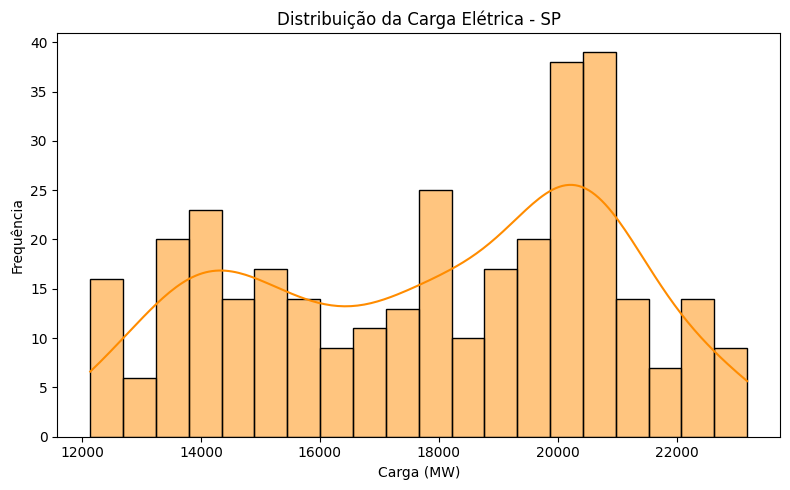

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(dados_final["carga_mw"], bins=20, kde=True, color="darkorange")
plt.title("Distribuição da Carga Elétrica - SP")
plt.xlabel("Carga (MW)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

A distribuição da carga não é simétrica: há uma concentração maior de registros na faixa entre
19.000 e 21.500 MW (as barras mais altas do histograma, próximas de 38-39 ocorrências), sugerindo
que boa parte do tempo a carga permanece nesse patamar mais elevado. Ao mesmo tempo, existe uma
quantidade razoável de registros espalhados pelas faixas mais baixas (entre 12.000 e 17.000 MW),
refletindo os períodos noturnos de menor consumo. A curva de densidade (KDE) reforça esse padrão,
com uma leve elevação bimodal — um platô mais baixo e uma concentração maior próxima do topo da
faixa de valores. Isso é coerente com o gráfico de linha: os valores mais baixos correspondem aos
vales noturnos, e a maior concentração próxima de 20.000 MW reflete o tempo prolongado que a curva
passa em patamares elevados durante o dia, antes de atingir os picos pontuais mais altos.

In [13]:
# DESAFIO 7

resumo_resultados = f'''
Regiao analisada: SP - Sao Paulo
Periodo analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {total_medicoes}
Carga minima: {carga_min:.2f} MW
Carga maxima: {carga_max:.2f} MW
Carga media: {carga_media:.2f} MW
Mediana: {carga_mediana:.2f} MW
Limiar de alta demanda: {limiar_alta_demanda:.2f} MW
Registros de alta demanda: {qtd_alta_demanda}
Percentual de alta demanda: {percentual_alta_demanda:.1f}%
Momento do pico: {pico_registro["data_hora"]}
Segundo criterio (acima da media): {qtd_acima_media} registros ({percentual_acima_media:.1f}%)
'''

print(resumo_resultados)


Regiao analisada: SP - Sao Paulo
Periodo analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga minima: 12139.25 MW
Carga maxima: 23185.31 MW
Carga media: 17870.83 MW
Mediana: 18199.13 MW
Limiar de alta demanda: 20866.78 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.9%
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo criterio (acima da media): 184 registros (54.8%)



In [14]:
# DESAFIO 8

prompt = f'''
Atue como analista de dados do setor eletrico.

Produza um relatorio tecnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Nao invente causas para as variacoes observadas.
Nao apresente como fato explicacoes que nao possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipoteses.

Inclua:
1. caracterizacao do conjunto analisado;
2. principais indicadores;
3. analise dos periodos de alta demanda;
4. comparacao com o segundo criterio;
5. conclusao.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

print(prompt)


Atue como analista de dados do setor eletrico.

Produza um relatorio tecnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Nao invente causas para as variacoes observadas.
Nao apresente como fato explicacoes que nao possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipoteses.

Inclua:
1. caracterizacao do conjunto analisado;
2. principais indicadores;
3. analise dos periodos de alta demanda;
4. comparacao com o segundo criterio;
5. conclusao.

RESULTADOS DA EQUIPE:


Regiao analisada: SP - Sao Paulo
Periodo analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga minima: 12139.25 MW
Carga maxima: 23185.31 MW
Carga media: 17870.83 MW
Mediana: 18199.13 MW
Limiar de alta demanda: 20866.78 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.9%
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo criterio (acima da media): 184 registros (54.8%)




## Desafio 9 — Validação Crítica

**Os indicadores foram utilizados corretamente?**

Sim. Todos os valores citados no relatório correspondem exatamente aos calculados em `resumo_resultados`.

**Há alguma afirmação que não pode ser confirmada pelos dados?**

Não de forma grave. O relatório é cuidadoso e reconhece que o conjunto de dados não permite atribuir o pico a fatores externos (temperatura, dia útil vs. fim de semana, eventos atípicos). O único ponto discutível foi a frase "confirma estatisticamente", que soa mais conclusiva do que os dados sustentam, já que nenhum teste estatístico formal foi realizado.

**Houve interpretação exagerada ou causalidade não demonstrada?**

Não houve causalidade não demonstrada. A única leve exageração foi o termo "confirma estatisticamente", corrigido na versão final.

**Que alterações a equipe realizou no texto?**

Foi substituído o trecho "a mediana... confirma estatisticamente a distribuição observada" por "é consistente com uma leve assimetria na distribuição", evitando linguagem que sugira um teste estatístico que não foi feito.

## Relatório Final

**Relatório Técnico: Análise da Carga Elétrica na Região SP - São Paulo**

**Para:** Gestão / Operação do Sistema Elétrico
**De:** Analista de Dados do Setor Elétrico
**Data:** 3 de Setembro de 2026
**Assunto:** Análise do Perfil de Demanda e Alta Carga no Período de 01/08/2025 a 07/08/2025

**1. Caracterização do Conjunto Analisado**

O conjunto de dados compreende a medição do comportamento da carga elétrica na região SP – São Paulo durante o período de 7 dias, cobrindo de 01/08/2025 a 07/08/2025. O total de observações é de 336 registros.

**2. Principais Indicadores**

| Indicador | Valor Observado |
|---|---|
| Carga Mínima | 12.139,25 MW |
| Carga Máxima (Pico) | 23.185,31 MW |
| Carga Média | 17.870,83 MW |
| Mediana | 18.199,13 MW |
| Momento do Pico | 01/08/2025 às 22:00:00 (UTC) |

**3. Análise dos Períodos de Alta Demanda**

Para o enquadramento de alta demanda, adotou-se o limiar de 20.866,78 MW.
- Registros observados: 50 registros atenderam a esse critério.
- Proporção: A alta demanda representou 14,9% do total de registros do período analisado.
- Mapeamento do pico: O valor máximo da série (23.185,31 MW) foi atingido em 01/08/2025 às 22:00:00 UTC.

**4. Comparação com o Segundo Critério**

- Critério 1 (Limiar de Alta Demanda > 20.866,78 MW): Captura 50 registros (14,9% do total).
- Critério 2 (Acima da Média > 17.870,83 MW): Captura 184 registros (54,8% do total).

A mediana (18.199,13 MW) superior à média (17.870,83 MW) é consistente com uma leve assimetria na distribuição da carga, na qual mais da metade do período opera acima do patamar médio do conjunto.

**5. Conclusão e Delimitação de Hipóteses**

Resultados Observados: O perfil de consumo da região SP entre 01/08/2025 e 07/08/2025 apresentou uma amplitude de variação de 11.046,06 MW entre a carga mínima e o pico. A operação em alta demanda severa representou 14,9% das observações, enquanto a carga permaneceu acima da média em 54,8% do tempo.

Hipóteses Não Comprovadas (Limitação dos Dados): O conjunto de dados fornecido restringe-se exclusivamente aos valores numéricos de carga e ao registro temporal. Não é possível afirmar factual ou objetivamente se o pico decorreu de condições meteorológicas, dinâmicas industriais, dias úteis versus finais de semana ou eventos atípicos na rede. Quaisquer atribuições a esses fatores devem ser tratadas estritamente como hipóteses externas.